# Power Demand Forecasting — End-to-End Notebook

**Goal:** predict the column `target` (energy consumption) using all the other features in the dataset.

**Primary metric:** MAPE (Mean Absolute Percentage Error) — lower is better.

This notebook walks through the project in plain language so you can follow every step.

**Sections**
1. Setup — import the libraries we need
2. Load the data — read the CSV file
3. Explore the data — quick look (EDA)
4. Visualise patterns — daily/weekly cycles
5. Feature engineering — turn timestamps + history into model inputs
6. Train / validation split — keep the LAST 20 % for testing
7. Train a LightGBM model
8. Evaluate — MAPE, MAE, RMSE
9. Explainability — which features matter most?
10. Save the model for later use

## 1. Setup

We import the libraries we will use:
- **pandas / numpy** — for tables of numbers
- **matplotlib / seaborn** — for charts
- **scikit-learn** — for metrics and helpers
- **lightgbm** — the model itself (fast and accurate on tabular data)

We also tell the notebook to find our own code under `src/` so we don't repeat ourselves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Our own modules
from data_loader import load_dataset, basic_clean, make_synthetic_dataset, TARGET_COLUMN
from feature_engineering import build_features, split_features_target
from model import time_based_split, train_model, save_model
from evaluate import regression_report, predictions_dataframe, feature_importance_dataframe


D:\data\dataset.csv


## 2. Load the data

We try to read the real CSV from `data/dataset.csv`.  If it isn't there yet we generate a *synthetic* dataset that has the same shape so we can still run the rest of the notebook.

> **Tip:** as soon as you copy the real CSV into `data/dataset.csv`, just re-run this cell — everything below adapts automatically.

In [2]:
# USE_SYNTHETIC = not DEFAULT_DATA_PATH.exists()

# if USE_SYNTHETIC:
#     print('Real CSV not found — using synthetic dataset for demo purposes.')
#     df_raw = make_synthetic_dataset()
#     ts_col = 'timestamp'
# else:
#     print(f'Loading real CSV from {DEFAULT_DATA_PATH}')
#     df_raw, ts_col = load_dataset(DEFAULT_DATA_PATH, target_column=TARGET_COLUMN)
df_raw = pd.read_csv('Energy_Dataset_ML.csv')

print('Shape:', df_raw.shape)
print('Timestamp column:', 'Time')
df_raw.head()

Shape: (40952, 23)
Timestamp column: Time


,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,target
0,04/10/2024 12:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,101.537338,526.225403,950.598267,317.534698,87.328026,908.293213,831.583679,1493.268188,728.515625,1522.5
1,04/10/2024 12:15,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,87.574669,512.467468,924.710449,219.791656,85.734978,44.133453,21.282021,0.000000,776.747009,1895.0
2,04/10/2024 12:30,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,67.657333,523.296082,923.986328,158.854156,88.341782,35.701073,644.438171,0.000000,748.914978,2572.5
3,04/10/2024 12:45,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,94.453339,543.406433,937.504272,179.861099,85.807388,280.516205,726.837707,0.000000,775.173645,2652.5
4,04/10/2024 13:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,96.096001,540.641663,949.533142,278.645813,84.866043,848.549438,815.185974,1540.173706,789.008301,2650.0


## 3. Quick exploration (EDA)

A first look at every column tells us:
- **dtype** — is it a number or text?
- **missing values** — do we need to fill any gaps?
- **mean / std / min / max** — typical ranges of each feature

In [3]:
print('Column types:')
print(df_raw.dtypes)
print('\nMissing values per column:',df_raw.isna().sum().sum())


Column types:
Time              str
feature_01    float64
feature_02    float64
feature_03    float64
feature_04    float64
feature_05    float64
feature_06    float64
feature_07    float64
feature_08    float64
feature_09    float64
feature_10    float64
feature_11    float64
feature_12    float64
feature_13    float64
feature_14    float64
feature_15    float64
feature_16    float64
feature_17    float64
feature_18    float64
feature_19    float64
feature_20    float64
feature_21    float64
target        float64
dtype: object

Missing values per column: 0


In [4]:
df_raw.describe().T  # one row per feature — easy to scan

,count,mean,std,min,25%,50%,75%,max
feature_01,40952.0,3902.156877,3273.622302,0.000000,0.000000,5230.995606,7016.287231,7960.601074
feature_02,40952.0,296.077828,195.739376,0.000000,0.000000,405.170288,439.703980,710.868530
feature_03,40952.0,152.886518,116.615331,0.000000,0.000000,191.872559,240.944824,559.914551
feature_04,40952.0,64.260022,47.732196,0.010820,16.053831,80.515156,110.621801,135.429352
feature_05,40952.0,120.809209,119.596579,0.000000,0.000000,59.266491,244.118912,300.000000
feature_06,40952.0,511.819294,333.285731,0.000000,0.000000,729.599976,742.400024,934.349976
feature_07,40952.0,76.340845,44.186931,0.115741,75.317356,96.166355,102.415964,200.000000
feature_08,40952.0,93.026896,55.513266,0.000000,53.427717,118.309258,134.888348,157.527710
feature_09,40952.0,86.606632,42.391359,0.096078,95.215353,105.227501,110.339472,200.000000
feature_10,40952.0,674.524511,356.913081,0.000000,128.000000,880.259003,900.078735,929.809082


### 3.1  Distribution of the target

How does the energy consumption (`target`) look?  Is it normal-ish, skewed, or full of outliers?

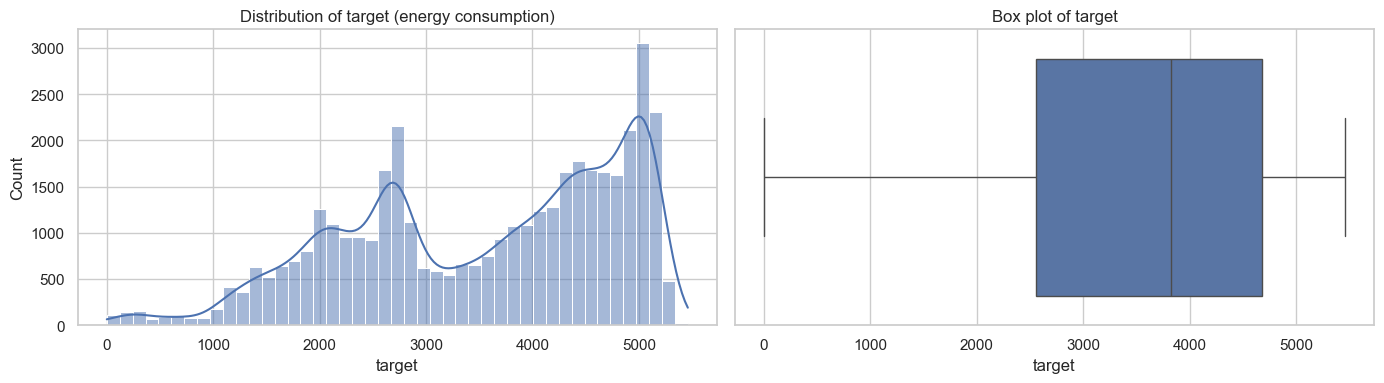

In [5]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_raw['target'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of target (energy consumption)')
sns.boxplot(x=df_raw['target'], ax=ax[1])
ax[1].set_title('Box plot of target')
plt.tight_layout()

## 4. Look at the time-series patterns

Energy consumption typically follows daily and weekly cycles (people use more power in the evening, less at night, less on weekends).  Let's confirm that.

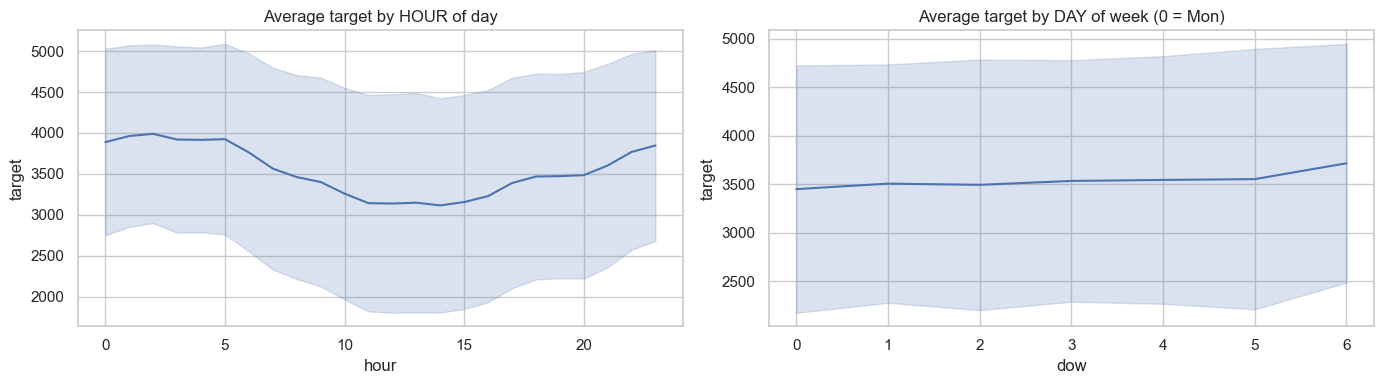

In [9]:
df_raw['Time'] = pd.to_datetime(df_raw['Time'])
ts_col = df_raw['Time'] 

# Assuming 'Time' is the timestamp column in the dataset

if ts_col is not None:
    tmp = df_raw[['Time', 'target']].copy()
    tmp['hour'] = tmp['Time'].dt.hour
    tmp['dow']  = tmp['Time'].dt.dayofweek

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    sns.lineplot(data=tmp, x='hour', y='target', ax=ax[0], errorbar='sd')
    ax[0].set_title('Average target by HOUR of day')
    sns.lineplot(data=tmp, x='dow', y='target', ax=ax[1], errorbar='sd')
    ax[1].set_title('Average target by DAY of week (0 = Mon)')
    plt.tight_layout()
else:
    print('No timestamp column detected — skipping time-series plots.')

### 4.1  Correlations between features and the target

Top-10 features most correlated with target:
feature_02    0.761841
feature_06    0.753656
feature_01    0.753444
feature_03    0.714707
feature_05    0.667011
feature_04   -0.417096
feature_20    0.358060
feature_12    0.350087
feature_15    0.346849
feature_14    0.338613
Name: target, dtype: float64


Text(0.5, 0, 'Pearson correlation')

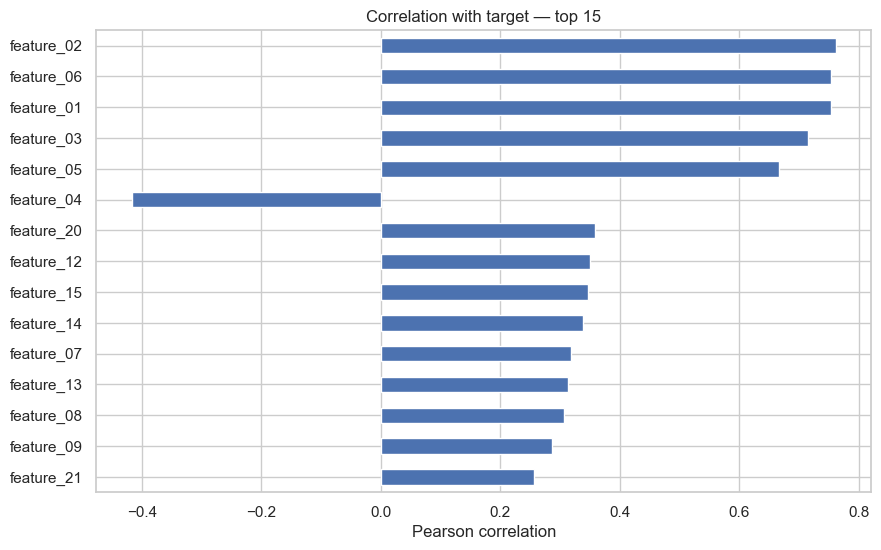

In [10]:
numeric_df = df_raw.select_dtypes(include='number')
corr_with_target = numeric_df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print('Top-10 features most correlated with target:')
print(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
corr_with_target.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Correlation with target — top 15')
plt.xlabel('Pearson correlation')

## 5. Feature engineering

We now create **new columns** that help the model:

- **Time features:** hour, day-of-week, month, plus sin/cos versions so the model knows that hour 23 is right next to hour 0.
- **Lag features:** the target's value 1, 24, and 168 hours ago — energy demand is highly correlated with itself.
- **Rolling features:** moving averages over the last few hours / day / week.

All of this is done by `build_features()` in `src/feature_engineering.py`.  Calling it from here keeps the notebook short.

In [13]:
df_clean = basic_clean(df_raw, target_column='target')
df_feat  = build_features(df_clean, ts_col=ts_col, target_col='target', use_lags=ts_col is not None)
print('Final shape after feature engineering:', df_feat.shape)
df_feat.head(3)

KeyError: "None of [DatetimeIndex(['2024-04-10 12:00:00', '2024-04-10 12:15:00',\n               '2024-04-10 12:30:00', '2024-04-10 12:45:00',\n               '2024-04-10 13:00:00', '2024-04-10 13:15:00',\n               '2024-04-10 13:30:00', '2024-04-10 13:45:00',\n               '2024-04-10 14:00:00', '2024-04-10 14:15:00',\n               ...\n               '2025-07-31 20:45:00', '2025-07-31 21:00:00',\n               '2025-07-31 21:15:00', '2025-07-31 21:30:00',\n               '2025-07-31 21:45:00', '2025-07-31 22:00:00',\n               '2025-07-31 22:15:00', '2025-07-31 22:30:00',\n               '2025-07-31 22:45:00', '2025-07-31 23:00:00'],\n              dtype='datetime64[us]', length=40952, freq=None)] are in the [columns]"

## 6. Train / validation split (time-based)

We keep the **last 20 %** of the rows (in chronological order) as our validation set.  This mimics real life: we train on the past and predict the future.

In [ ]:
X, y = split_features_target(df_feat, target_col=TARGET_COLUMN, ts_col=ts_col)
X_train, X_valid, y_train, y_valid = time_based_split(X, y, valid_fraction=0.2)
print('Train rows:', len(X_train), '| Valid rows:', len(X_valid))
print('Number of features:', X.shape[1])

## 7. Train the model

We use **LightGBM**, a gradient-boosting tree library.  We give it the validation set so it can stop training automatically when the score stops improving ("early stopping").

In [ ]:
result = train_model(X_train, y_train, X_valid, y_valid)
print(type(result.model).__name__, 'trained on', result.train_size, 'rows.')

## 8. Evaluate

We compute three metrics on the held-out validation set:
- **MAPE** — primary metric for the assignment.
- **MAE** — average absolute error in raw units.
- **RMSE** — heavier penalty for big mistakes.

In [ ]:
y_pred = result.model.predict(X_valid)
metrics = regression_report(y_valid.values, y_pred)
print('Validation metrics:')
for k, v in metrics.items():
    print(f'  {k:>8}: {v}')

In [ ]:
# Plot actual vs predicted over time
pred_df = predictions_dataframe(
    y_valid.values,
    y_pred,
    timestamps=df_feat.iloc[X_valid.index][ts_col] if ts_col else None,
)

plt.figure(figsize=(14, 4))
if 'timestamp' in pred_df.columns:
    plt.plot(pred_df['timestamp'], pred_df['actual'], label='Actual', alpha=0.8)
    plt.plot(pred_df['timestamp'], pred_df['predicted'], label='Predicted', alpha=0.8)
    plt.xlabel('Time')
else:
    plt.plot(pred_df['actual'].values[:500], label='Actual', alpha=0.8)
    plt.plot(pred_df['predicted'].values[:500], label='Predicted', alpha=0.8)
plt.title('Actual vs predicted energy consumption (validation set)')
plt.legend()
plt.tight_layout()

In [ ]:
# Error distribution — how big are our mistakes?
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(pred_df['error'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of errors  (actual − predicted)')
ax[0].axvline(0, color='red', linestyle='--')
sns.scatterplot(data=pred_df, x='actual', y='predicted', ax=ax[1], alpha=0.3)
lims = [pred_df['actual'].min(), pred_df['actual'].max()]
ax[1].plot(lims, lims, color='red', linestyle='--')
ax[1].set_title('Predicted vs Actual — points on the red line are perfect')
plt.tight_layout()

## 9. Explainability — which features matter?

Two views:
1. **Feature importance** straight from the model (fast).
2. **SHAP** values for the top features (rigorous but slower).

In [ ]:
fi = feature_importance_dataframe(result.model, result.feature_names)
print('Top-15 most important features:')
print(fi.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi.head(15), x='importance_pct', y='feature')
plt.title('Feature importance (top 15)')
plt.xlabel('Importance (% of total)')

In [ ]:
# SHAP is heavier — wrap it in try/except so it's optional.
try:
    import shap
    explainer = shap.TreeExplainer(result.model)
    sample_idx = np.random.choice(len(X_valid), size=min(1000, len(X_valid)), replace=False)
    shap_values = explainer.shap_values(X_valid.iloc[sample_idx])
    shap.summary_plot(shap_values, X_valid.iloc[sample_idx], plot_type='bar', show=True)
    shap.summary_plot(shap_values, X_valid.iloc[sample_idx], show=True)
except Exception as exc:
    print('SHAP not available or failed:', exc)

## 10. Save the trained model

We use `joblib` to write the model and its column names to disk.  The Streamlit app and `test_model.py` will reload from that same file.

In [ ]:
out_path = save_model(result)
print('Saved model to:', out_path)

## Recap & next steps

- We loaded the dataset, looked at it, and confirmed the expected daily/weekly cycles.
- We engineered time, lag, and rolling features.
- We trained a LightGBM model with proper time-based validation.
- We reported MAPE/MAE/RMSE and visualised actual vs predicted.
- We explained the model using built-in feature importance and SHAP.
- We saved the model so it can be reused by `frontend/app.py` (Streamlit UI) and by `test_model.py`.

**Production deployment outline (assignment section C):**
- Ingest sensor data → buffer in a message queue (e.g. Kafka).
- A scheduled job pulls features, calls the model, writes predictions to a time-series DB.
- A dashboard (the Streamlit app here) reads from the DB and visualises forecasts.
- Retrain weekly (or when drift exceeds a threshold) — monitor MAPE on a rolling basis to trigger retraining automatically.